# Hera — inteligentná kompresia snímok (tile-selection pipeline)

Experiment z repo [michalnand/sw_experiments_hera](https://github.com/michalnand/sw_experiments_hera)
pre sandbox ESA misie **Hera** (Core 1). Namiesto posielania celého rámčeka na Zem
pipeline na palube vyhodnotí **ktoré 16×16 dlaždice (tile-y) sú vedecky zaujímavé**
(krátery, balvany, terén) a ostatné zahodí — šetrí downlink.

Postup: **tiling → features → skórovanie → quadtree merge → report**.

▶ Otvoriť v Colab:
`https://colab.research.google.com/github/Marek-maker/sw_experiments_hera/blob/main/notebooks/hera_image_compression_demo.ipynb`

> Beží aj lokálne — stačí spustiť bunky po jednej (Ctrl+Enter).

## 0. Inštalácia balíkov (Colab ich má predinštalované — bunka sa preskočí)

In [1]:
import importlib.util, subprocess, sys

missing = [p for p in ("cv2", "sklearn", "matplotlib") if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                           "numpy", "opencv-python", "scikit-learn", "matplotlib"])
    print("nainštalované:", missing)
else:
    print("všetky balíky už sú — preskakujem.")

všetky balíky už sú — preskakujem.


## 1. Dáta — snímky kométy 67P (Rosetta NavCam)

stiahnuté: Comet_from_17.4_km_NavCam.jpg


stiahnuté: Comet_from_19.4_km_NavCam.jpg


stiahnuté: Comet_from_20_km_NavCam.jpg


stiahnuté: Comet_on_10_February_2016_NavCam.jpg


stiahnuté: Comet_on_15_April_2015_b_NavCam.jpg
snímka: Comet_from_20_km_NavCam.jpg | rozmery: (1024, 1024)


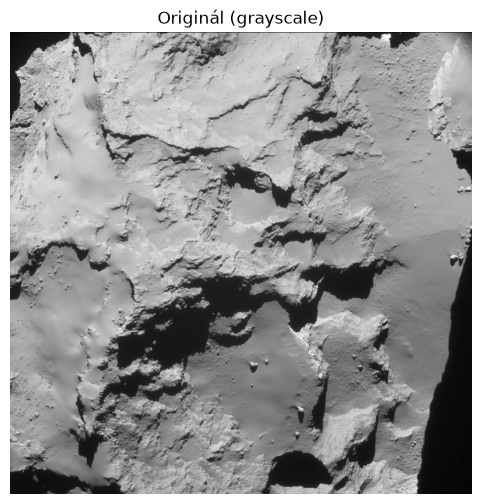

In [2]:
import os, urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
%matplotlib inline

# 5 ukážkových snímok kométy 67P/Churyumov-Gerasimenko
FILES = [
    "Comet_from_17.4_km_NavCam.jpg",
    "Comet_from_19.4_km_NavCam.jpg",
    "Comet_from_20_km_NavCam.jpg",
    "Comet_on_10_February_2016_NavCam.jpg",
    "Comet_on_15_April_2015_b_NavCam.jpg",
]
BASE = "https://raw.githubusercontent.com/michalnand/sw_experiments_hera/main/image_compression/data/"

os.makedirs("data", exist_ok=True)
for f in FILES:
    path = os.path.join("data", f)
    if not os.path.exists(path):
        urllib.request.urlretrieve(BASE + f, path)
        print("stiahnuté:", f)
    else:
        print("existuje:", f)

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    assert img is not None, f"nepodarilo sa načítať {path}"
    return np.array(img / 255.0, dtype=np.float32)

img = load_image(os.path.join("data", FILES[2]))
print("snímka:", FILES[2], "| rozmery:", img.shape)
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray", vmin=0, vmax=1)
plt.title("Originál (grayscale)")
plt.axis("off")
plt.show()

## 2. Krok 1 — Tiling do 4D tenzora

Obrázok orežeme na násobok `TILE_SIZE=16` a reshape-ujeme do tvaru
`(grid_h, grid_w, 16, 16)` — **bez jedinej slučky**, čisto vektorizovane.
To je kľúčové pre letový procesor LEON3, ktorý nemá výkon na per-tile slučky.

In [3]:
TILE_SIZE = 16

def make_tiles(image, tile_size=TILE_SIZE):
    grid_h, grid_w = image.shape[0] // tile_size, image.shape[1] // tile_size
    cropped = image[:grid_h * tile_size, :grid_w * tile_size]
    return cropped.reshape(grid_h, tile_size, grid_w, tile_size).swapaxes(1, 2)

tiles = make_tiles(img)
print("tvar tenzora (grid_h, grid_w, tile_h, tile_w):", tiles.shape)
print("počet tile-ov:", tiles.shape[0] * tiles.shape[1])

tvar tenzora (grid_h, grid_w, tile_h, tile_w): (64, 64, 16, 16)
počet tile-ov: 4096


## 3. Krok 2 — Feature extraction (per tile)

Každý tile zjednodušíme na 4 čísla, ktoré vystihujú lokálnu štruktúru povrchu:

| feature | význam |
|---|---|
| **mean** | priemerná jasnosť (základný jas) |
| **std** | drsnosť / textúra povrchu |
| **gradient** | hustota hrán (Sobel surrogate) |
| **outliers** | podiel pixelov nad 1.5σ od priemeru (zachytáva ostré anomálie) |

Prázdny vesmír má std≈0 aj gradient≈0 → neskôr dostane skóre ~0.

In [4]:
def extract_features(image, tile_size=TILE_SIZE):
    grid_h, grid_w = image.shape[0] // tile_size, image.shape[1] // tile_size
    cropped = image[:grid_h * tile_size, :grid_w * tile_size]
    tiles = cropped.reshape(grid_h, tile_size, grid_w, tile_size).swapaxes(1, 2)

    f_mean = np.mean(tiles, axis=(2, 3))
    f_std  = np.std(tiles, axis=(2, 3))
    gx = np.abs(np.diff(tiles, axis=3)).sum(axis=(2, 3))
    gy = np.abs(np.diff(tiles, axis=2)).sum(axis=(2, 3))
    f_grad = (gx + gy) / (tile_size * tile_size)

    mean_bc = f_mean[:, :, None, None]
    std_bc  = f_std[:, :, None, None] + 1e-7
    f_outliers = np.mean(np.abs(tiles - mean_bc) > (1.5 * std_bc), axis=(2, 3))

    return np.stack([f_mean, f_std, f_grad, f_outliers], axis=-1)

features = extract_features(img)
print("feature grid:", features.shape, "(grid_h, grid_w, 4 featúry)")
print("príklad — tile [30, 30]:", np.round(features[30, 30], 4))

feature grid: (64, 64, 4) (grid_h, grid_w, 4 featúry)
príklad — tile [30, 30]: [0.8065 0.0476 0.0579 0.1133]


## 4. Krok 3 — Skórovanie zaujímavosti

Dva módy:

1. **Heuristika** (`score_tiles`) — priemer featúr, min-max normalizácia na [0,1],
   potom dilácia + blur (spojí susedné vrcholy do kompaktných blokov, nech quadtree
   neseká na šum).
2. **IsolationForest** (`score_tiles_iforest`) — unsupervised ML: naučí sa "normálny"
   povrch a označí vzácne textúry ako anomálie. Mŕtve (čierne) tile-y sa najprv
   zamaskujú, aby ich les nebral ako najvzácnejšiu anomáliu.

C:\Users\ratze\AppData\Local\Temp\ipykernel_8212\3854717334.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


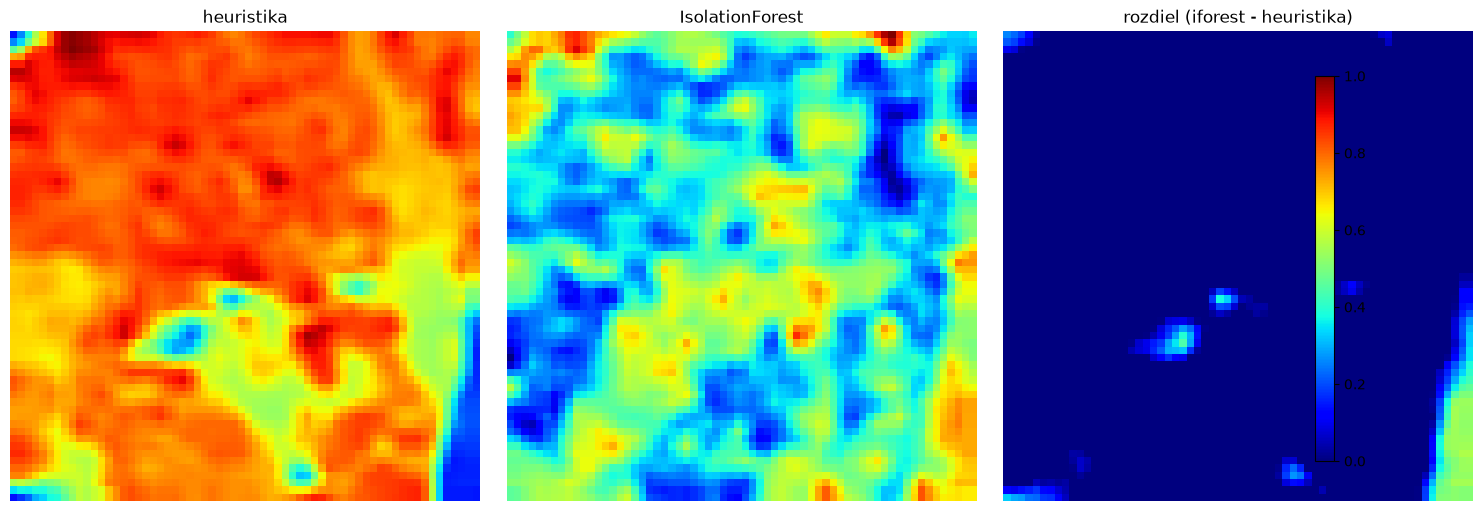

heuristika:   min=0.139 max=1.000
iforest:      min=0.000 max=1.000


In [5]:
def score_tiles(features, blur_kernel=3):
    raw = features.mean(axis=-1).astype(np.float32)
    mx, mn = raw.max(), raw.min()
    scores = (raw - mn) / (mx - mn) if mx > mn else np.zeros_like(raw)
    if blur_kernel > 1:
        scores = cv2.dilate(scores, np.ones((blur_kernel, blur_kernel), np.float32))
        scores = cv2.blur(scores, (blur_kernel, blur_kernel))
    return np.clip(scores, 0.0, 1.0)

def score_tiles_iforest(features, blur_kernel=3):
    gh, gw, nf = features.shape
    flat = features.reshape(-1, nf)
    valid = flat[:, 1] > 1e-5                      # len tile-y s textúrou
    scores_flat = np.zeros(flat.shape[0], dtype=np.float32)
    if np.any(valid):
        clf = IsolationForest(n_estimators=64, max_samples=512)
        clf.fit(flat[valid])
        raw = -clf.score_samples(flat[valid])
        mn, mx = raw.min(), raw.max()
        scores_flat[valid] = (raw - mn) / (mx - mn) if mx > mn else 0.0
    scores = scores_flat.reshape(gh, gw)
    scores[scores < 0.15] = 0.0
    if blur_kernel > 1:
        k = np.ones((blur_kernel, blur_kernel), np.float32)
        scores = cv2.blur(cv2.dilate(scores, k), (blur_kernel, blur_kernel))
    return np.clip(scores, 0.0, 1.0)

scores_heur = score_tiles(features)
scores_if   = score_tiles_iforest(features)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, s, t in [(axes[0], scores_heur, "heuristika"), (axes[1], scores_if, "IsolationForest"),
                 (axes[2], scores_if - scores_heur, "rozdiel (iforest - heuristika)")]:
    im = ax.imshow(s, cmap="jet", vmin=0, vmax=1)
    ax.set_title(t)
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.02)
plt.tight_layout()
plt.show()
print(f"heuristika:   min={scores_heur.min():.3f} max={scores_heur.max():.3f}")
print(f"iforest:      min={scores_if.min():.3f} max={scores_if.max():.3f}")

## 5. Krok 4 — Quadtree merge (obdĺžniky na poslanie)

`merge_tiles_q` rekurzívne delí grid na kvadranty a rozhoduje:

- celý blok pod prahom → **zahodí (0 bajtov)**
- blok homogénny a pod limitom veľkosti → **zlepí do jedného obdĺžnika**
- inak → rozdelí a skúša kvadranty ďalej

Výstup: zoznam `(x, y, w, h, avg_score)` v pixeloch, zoradený podľa priority.

In [6]:
def merge_tiles_q(score_grid, tile_size=TILE_SIZE, min_score_threshold=0.4,
                  max_score_std=0.15, max_block_tiles=8):
    rectangles = []

    def split(r, c, h, w):
        region = score_grid[r:r + h, c:c + w]
        max_val, min_val = region.max(), region.min()
        avg_val, std_dev = float(region.mean()), float(region.std())

        if max_val < min_score_threshold:          # celý blok pod prahom -> 0 bajtov
            return
        atomic = (h == 1 and w == 1)
        too_big = (h > max_block_tiles or w > max_block_tiles)
        prunable = min_val < min_score_threshold   # dá sa niečo vnútri zahodiť?

        if not atomic and not too_big and not prunable and std_dev <= max_score_std:
            rectangles.append((c * tile_size, r * tile_size, w * tile_size, h * tile_size, avg_val))
            return
        if atomic:
            rectangles.append((c * tile_size, r * tile_size, tile_size, tile_size, avg_val))
            return

        mh, mw = max(1, h // 2), max(1, w // 2)
        for sub_r, sub_h in ([(r, mh), (r + mh, h - mh)] if h > 1 else [(r, 1)]):
            for sub_c, sub_w in ([(c, mw), (c + mw, w - mw)] if w > 1 else [(c, 1)]):
                if sub_h > 0 and sub_w > 0:
                    split(sub_r, sub_c, sub_h, sub_w)

    gh, gw = score_grid.shape
    split(0, 0, gh, gw)
    rectangles.sort(key=lambda it: it[4], reverse=True)
    return rectangles

rects_heur = merge_tiles_q(scores_heur, min_score_threshold=0.5, max_block_tiles=16)
rects_if   = merge_tiles_q(scores_if,   min_score_threshold=0.5, max_block_tiles=16)
print(f"heuristika: {len(rects_heur)} obdĺžnikov")
print(f"iforest:    {len(rects_if)} obdĺžnikov")
print("top 3 (heuristika):", [tuple(np.round(r[:4]).astype(int)) + (round(r[4], 3),) for r in rects_heur[:3]])

heuristika: 159 obdĺžnikov
iforest:    508 obdĺžnikov
top 3 (heuristika): [(np.int64(128), np.int64(0), np.int64(128), np.int64(128), 0.916), (np.int64(480), np.int64(512), np.int64(32), np.int64(32), 0.915), (np.int64(0), np.int64(64), np.int64(64), np.int64(64), 0.904)]


## 6. Krok 5 — Vizualizácia výberu

2×2 grid: originál · heatmapa skóre · obdĺžniky · **len vybrané tile-y**.

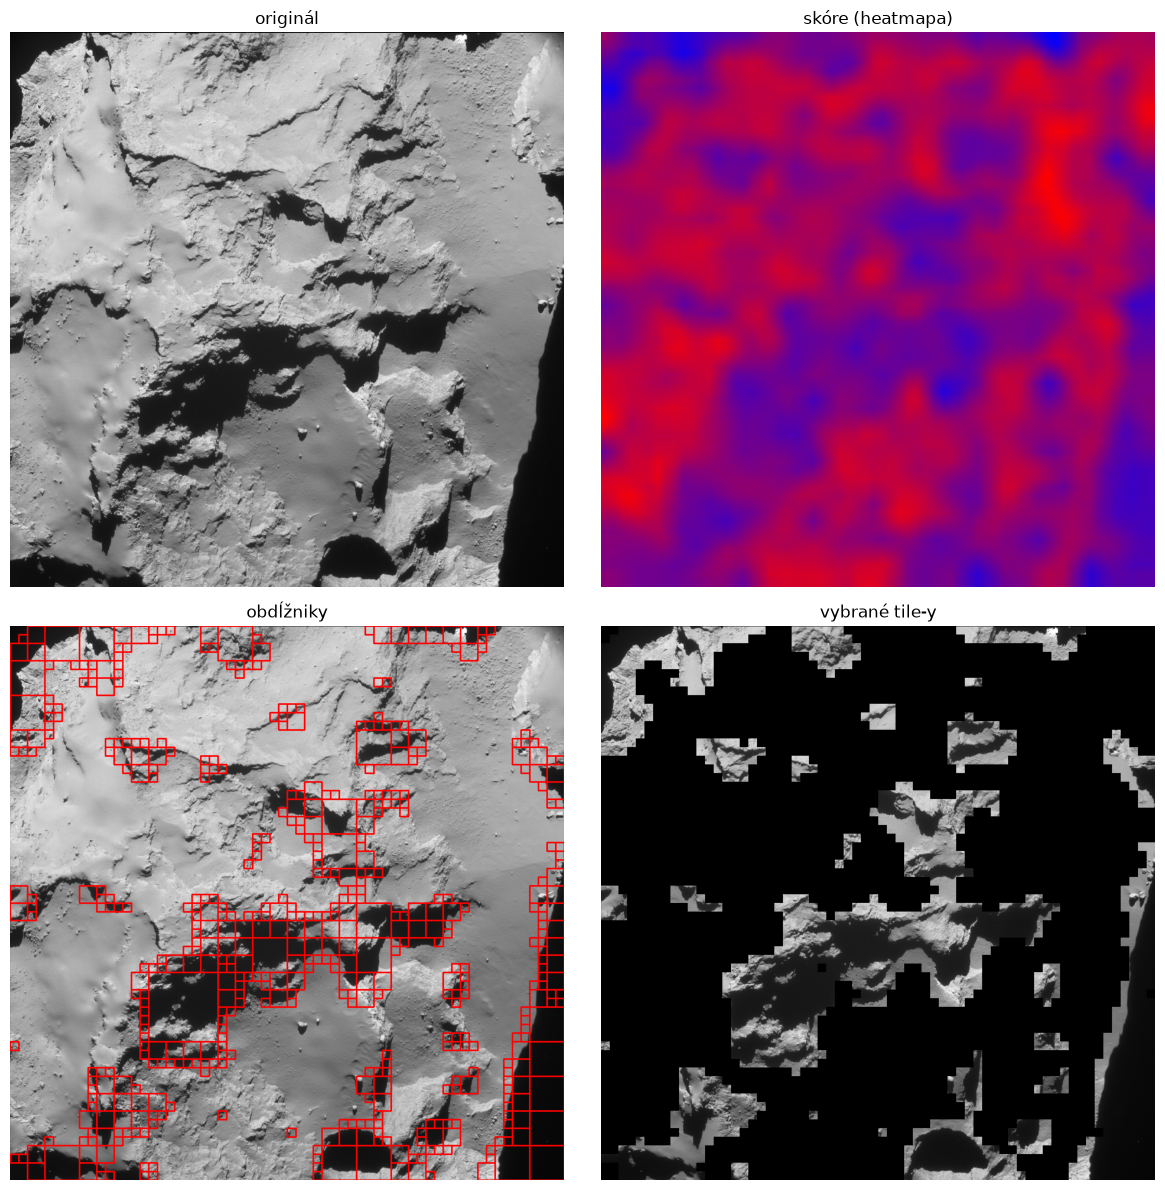

In [7]:
def build_quadrants(image, scores, rectangles):
    h, w = image.shape
    img_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    s = cv2.resize(scores, (w, h), interpolation=cv2.INTER_LINEAR)[..., None]
    blue = np.zeros((1, 1, 3)); blue[0, 0, 0] = 1.0
    red  = np.zeros((1, 1, 3)); red[0, 0, 2] = 1.0
    heat = (1.0 - s) * blue + s * red

    img_tiles = np.array(img_rgb)
    img_sel = np.zeros_like(img_rgb)
    for x, y, bw, bh, _ in rectangles:
        img_tiles = cv2.rectangle(img_tiles, (x, y), (x + bw, y + bh), (1, 0, 0), 2)
        img_sel[y:y + bh, x:x + bw] = img_rgb[y:y + bh, x:x + bw]
    return img_rgb, heat, img_tiles, img_sel

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
quads = build_quadrants(img, scores_if, rects_if)
titles = ["originál", "skóre (heatmapa)", "obdĺžniky", "vybrané tile-y"]
for ax, quad, t in zip(axes.flat, quads, titles):
    ax.imshow(quad)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Krok 6 — Koľko sa reálne pošle na Zem?

Ak pošleme len vybrané obdĺžniky + metadáta (x, y, w, h, skóre), koľko bajtov
ušetríme oproti celému rámčeku?

In [8]:
def bandwidth_report(image, rectangles):
    h, w = image.shape
    sel_px = sum(bw * bh for _, _, bw, bh, _ in rectangles)
    meta = len(rectangles) * 5 * 4                     # 5 intov * 4 B na obdĺžnik
    payload = sel_px + meta
    print(f"  obrázok: {w}x{h} px = {h * w} px")
    print(f"  obdĺžnikov: {len(rectangles)}")
    print(f"  vybraných pixelov: {sel_px} ({100.0 * sel_px / (h * w):.1f}% snímky)")
    print(f"  payload (px + metadáta): {payload} B = {100.0 * payload / (h * w):.1f}% oproti celému rámčeku")
    return 100.0 * payload / (h * w)

print("--- HEURISTIKA ---")
bandwidth_report(img, rects_heur)
print("\n--- ISOLATION FOREST ---")
bandwidth_report(img, rects_if)

--- HEURISTIKA ---
  obrázok: 1024x1024 px = 1048576 px
  obdĺžnikov: 159
  vybraných pixelov: 997632 (95.1% snímky)
  payload (px + metadáta): 1000812 B = 95.4% oproti celému rámčeku

--- ISOLATION FOREST ---
  obrázok: 1024x1024 px = 1048576 px
  obdĺžnikov: 508
  vybraných pixelov: 324352 (30.9% snímky)
  payload (px + metadáta): 334512 B = 31.9% oproti celému rámčeku


31.90155029296875

## 8. Porovnanie na všetkých 5 snímkach

Rovnaký pipeline na ostatných obrázkoch — ukážka univerzálnosti.
Zaujímavé: keď kométa vypĺňa celý záber, pošle sa skoro všetko (všetko je
zaujímavé); keď je malá v čiernom priestore, ušetríme 7–8×.

snímka                                 rozmery      obdĺžnikov  poslaných px
------------------------------------------------------------------------------
Comet_from_17.4_km_NavCam.jpg          (1024, 1024)        657        40.2%
Comet_from_19.4_km_NavCam.jpg          (1024, 1024)        752        51.5%
Comet_from_20_km_NavCam.jpg            (1024, 1024)        541        37.1%
Comet_on_10_February_2016_NavCam.jpg   (1024, 1024)        488        41.7%
Comet_on_15_April_2015_b_NavCam.jpg    (738, 738)           92        14.4%


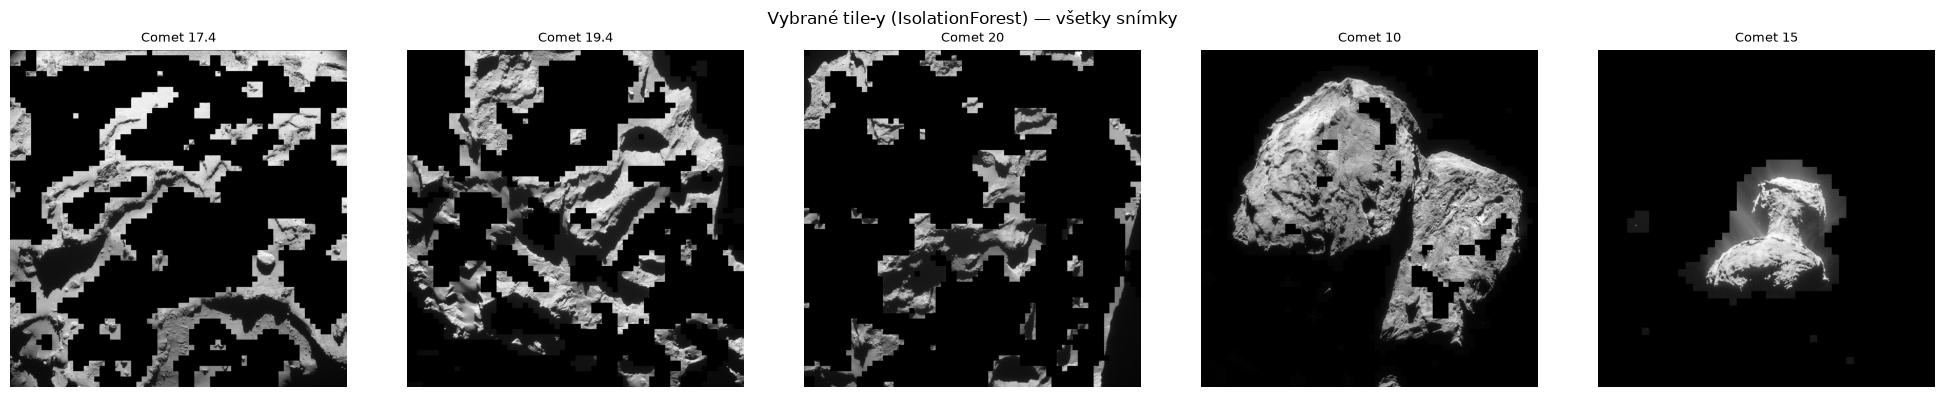

In [9]:
rows = []
for f in FILES:
    im = load_image(os.path.join("data", f))
    feats = extract_features(im)
    s_if = score_tiles_iforest(feats)
    r_if = merge_tiles_q(s_if, min_score_threshold=0.5, max_block_tiles=16)

    sel = sum(bw * bh for _, _, bw, bh, _ in r_if)
    pct = 100.0 * sel / im.size
    rows.append((f, im.shape, len(r_if), pct))

print(f"{'snímka':<38} {'rozmery':<12} {'obdĺžnikov':>10} {'poslaných px':>13}")
print("-" * 78)
for name, shape, n, pct in rows:
    print(f"{name:<38} {str(shape):<12} {n:>10} {pct:>11.1f}%")

# malý prehľad: vybrané tile-y všetkých snímok
fig, axes = plt.subplots(1, len(FILES), figsize=(20, 4))
for ax, f in zip(axes, FILES):
    im = load_image(os.path.join("data", f))
    feats = extract_features(im)
    s_if = score_tiles_iforest(feats)
    r_if = merge_tiles_q(s_if, min_score_threshold=0.5, max_block_tiles=16)
    _, _, _, sel_quad = build_quadrants(im, s_if, r_if)
    ax.imshow(sel_quad)
    ax.set_title(f.split("_")[0] + " " + f.split("_")[2], fontsize=9)
    ax.axis("off")
plt.suptitle("Vybrané tile-y (IsolationForest) — všetky snímky")
plt.tight_layout()
plt.show()

## Záver

Pipeline vyhodnotí záujem per-tile, zlepí ho do obdĺžnikov a pošle na Zem
len to podstatné + malé metadáta. Pri snímkach s kométou v čiernom priestore
je úspora prenosu **7–8×**; pri záberoch, kde kométa vypĺňa rám, sa pošle
takmer všetko — čo je správne, lebo všetko je vedecky hodnotné.

Experimentuj: zmeň `TILE_SIZE`, `min_score_threshold`, `max_block_tiles`
alebo vyskúšaj `score_tiles` (heuristiku) namiesto iforest-u.